In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings

from visions.backends.python.types import time

# from ydata_profiling import ProfileReport
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

df=pd.read_csv("C:/Users/yahia/PycharmProjects/JupyterProject3/data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [2]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:

# 1. Fix TotalCharges: Convert blank spaces to NaN and change data type to float
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = df['TotalCharges'].astype(float)

# 2. Handle missing values created in TotalCharges (impute with 0 since tenure is 0)
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)

# 3. Convert SeniorCitizen from 0/1 to Yes/No for consistency with Partner/Dependents
df['SeniorCitizen'] = df['SeniorCitizen'].map({1: 'Yes', 0: 'No'})

# 4. Drop customerID if you are preparing this data for machine learning
df = df.drop(columns=['customerID'])

# Verify the changes
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   object 
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [6]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [7]:
categorical_cols = df.select_dtypes(include=['object']).columns

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   object 
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [9]:
df.to_string()
df.describe()

scaler = StandardScaler()
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   object 
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [11]:
df.describe()

,tenure,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304,0.265370
std,24.559481,30.090047,2266.794470,0.441561
min,0.000000,18.250000,0.000000,0.000000
25%,9.000000,35.500000,398.550000,0.000000
50%,29.000000,70.350000,1394.550000,0.000000
75%,55.000000,89.850000,3786.600000,1.000000
max,72.000000,118.750000,8684.800000,1.000000


In [12]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [13]:
object_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=object_cols, drop_first=True)

bool_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

# Verify that no object columns remain
print(df_encoded.dtypes.value_counts())

int64      29
float64     2
Name: count, dtype: int64


In [22]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   tenure                                 7043 non-null   int64  
 1   MonthlyCharges                         7043 non-null   float64
 2   TotalCharges                           7043 non-null   float64
 3   Churn                                  7043 non-null   int64  
 4   gender_Male                            7043 non-null   int64  
 5   SeniorCitizen_Yes                      7043 non-null   int64  
 6   Partner_Yes                            7043 non-null   int64  
 7   Dependents_Yes                         7043 non-null   int64  
 8   PhoneService_Yes                       7043 non-null   int64  
 9   MultipleLines_No phone service         7043 non-null   int64  
 10  MultipleLines_Yes                      7043 non-null   int64  
 11  Inte

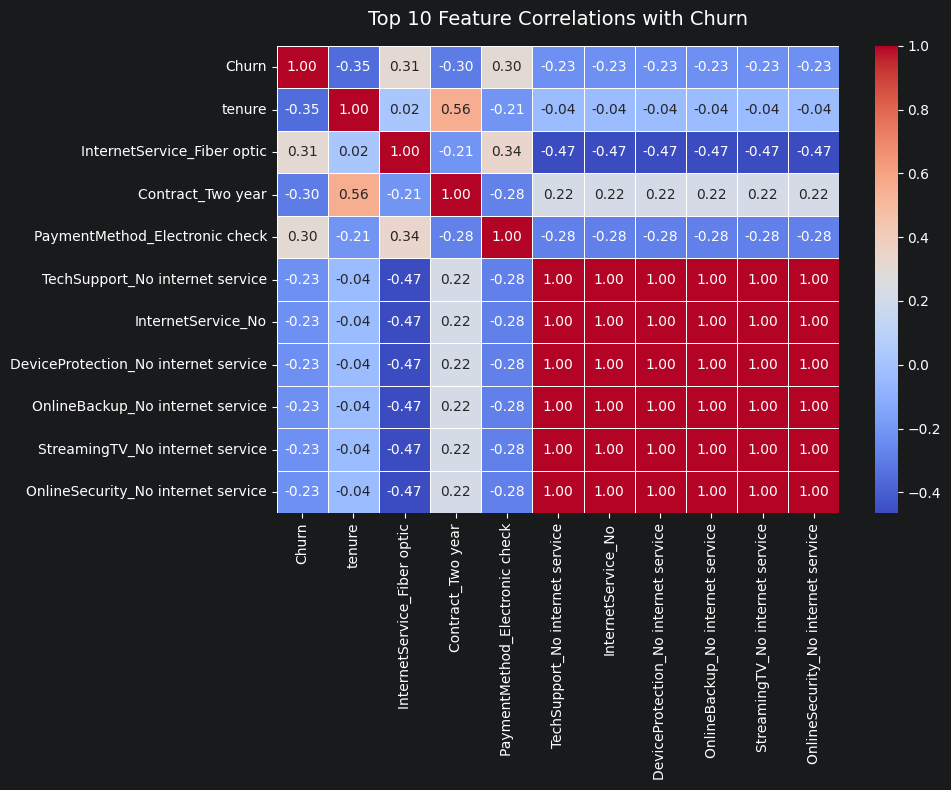

In [24]:
churn_correlation = df_encoded.corr()['Churn'].sort_values(ascending=False)

top_features = churn_correlation.abs().sort_values(ascending=False).index[:11] # Top 10 + Churn itself
top_corr_matrix = df_encoded[top_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(top_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Top 10 Feature Correlations with Churn", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [25]:
print(churn_correlation.head(6))
print(churn_correlation.tail(5))

Churn                             1.000000
InternetService_Fiber optic       0.308020
PaymentMethod_Electronic check    0.301919
MonthlyCharges                    0.193356
PaperlessBilling_Yes              0.191825
SeniorCitizen_Yes                 0.150889
Name: Churn, dtype: float64
DeviceProtection_No internet service   -0.227890
StreamingMovies_No internet service    -0.227890
TechSupport_No internet service        -0.227890
Contract_Two year                      -0.302253
tenure                                 -0.352229
Name: Churn, dtype: float64


In [26]:
low_corr_cutoff = 0.02
features_to_drop = churn_correlation[churn_correlation.abs() < low_corr_cutoff].index
df_filtered = df_encoded.drop(columns=features_to_drop)


X = df_filtered.drop(columns=['Churn'])
y = df_filtered['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   tenure                                 7043 non-null   int64  
 1   MonthlyCharges                         7043 non-null   float64
 2   TotalCharges                           7043 non-null   float64
 3   Churn                                  7043 non-null   int64  
 4   SeniorCitizen_Yes                      7043 non-null   int64  
 5   Partner_Yes                            7043 non-null   int64  
 6   Dependents_Yes                         7043 non-null   int64  
 7   MultipleLines_Yes                      7043 non-null   int64  
 8   InternetService_Fiber optic            7043 non-null   int64  
 9   InternetService_No                     7043 non-null   int64  
 10  OnlineSecurity_No internet service     7043 non-null   int64  
 11  Onli

In [28]:
print(df_filtered.head(100))

    tenure  MonthlyCharges  TotalCharges  Churn  SeniorCitizen_Yes  \
0        1           29.85         29.85      0                  0   
1       34           56.95       1889.50      0                  0   
2        2           53.85        108.15      1                  0   
3       45           42.30       1840.75      0                  0   
4        2           70.70        151.65      1                  0   
..     ...             ...           ...    ...                ...   
95      12           78.95        927.35      1                  0   
96      71           66.85       4748.70      0                  0   
97       5           21.05        113.85      1                  0   
98      52           21.00       1107.20      0                  0   
99      25           98.50       2514.50      1                  1   

    Partner_Yes  Dependents_Yes  MultipleLines_Yes  \
0             1               0                  0   
1             0               0                  0 

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    print(f" {name}perfomance")
    print(classification_report(y_test, preds))
    print(f"Overall Accuracy: {accuracy_score(y_test, preds):.2%}\n")


 Logistic Regressionperfomance
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409

Overall Accuracy: 74.17%

 Decision Treeperfomance
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1035
           1       0.50      0.81      0.62       374

    accuracy                           0.73      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.73      0.75      1409

Overall Accuracy: 73.46%

 Random Forestperfomance
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1035
           1       0.55      0.63      0.59       374

    accuracy                           0.77      

In [31]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   tenure                                 7043 non-null   int64  
 1   MonthlyCharges                         7043 non-null   float64
 2   TotalCharges                           7043 non-null   float64
 3   Churn                                  7043 non-null   int64  
 4   SeniorCitizen_Yes                      7043 non-null   int64  
 5   Partner_Yes                            7043 non-null   int64  
 6   Dependents_Yes                         7043 non-null   int64  
 7   MultipleLines_Yes                      7043 non-null   int64  
 8   InternetService_Fiber optic            7043 non-null   int64  
 9   InternetService_No                     7043 non-null   int64  
 10  OnlineSecurity_No internet service     7043 non-null   int64  
 11  Onli

In [32]:
df_filtered.head()

,tenure,MonthlyCharges,TotalCharges,Churn,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,29.85,29.85,0,0,1,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
1,34,56.95,1889.50,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,2,53.85,108.15,1,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
3,45,42.30,1840.75,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4,2,70.70,151.65,1,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


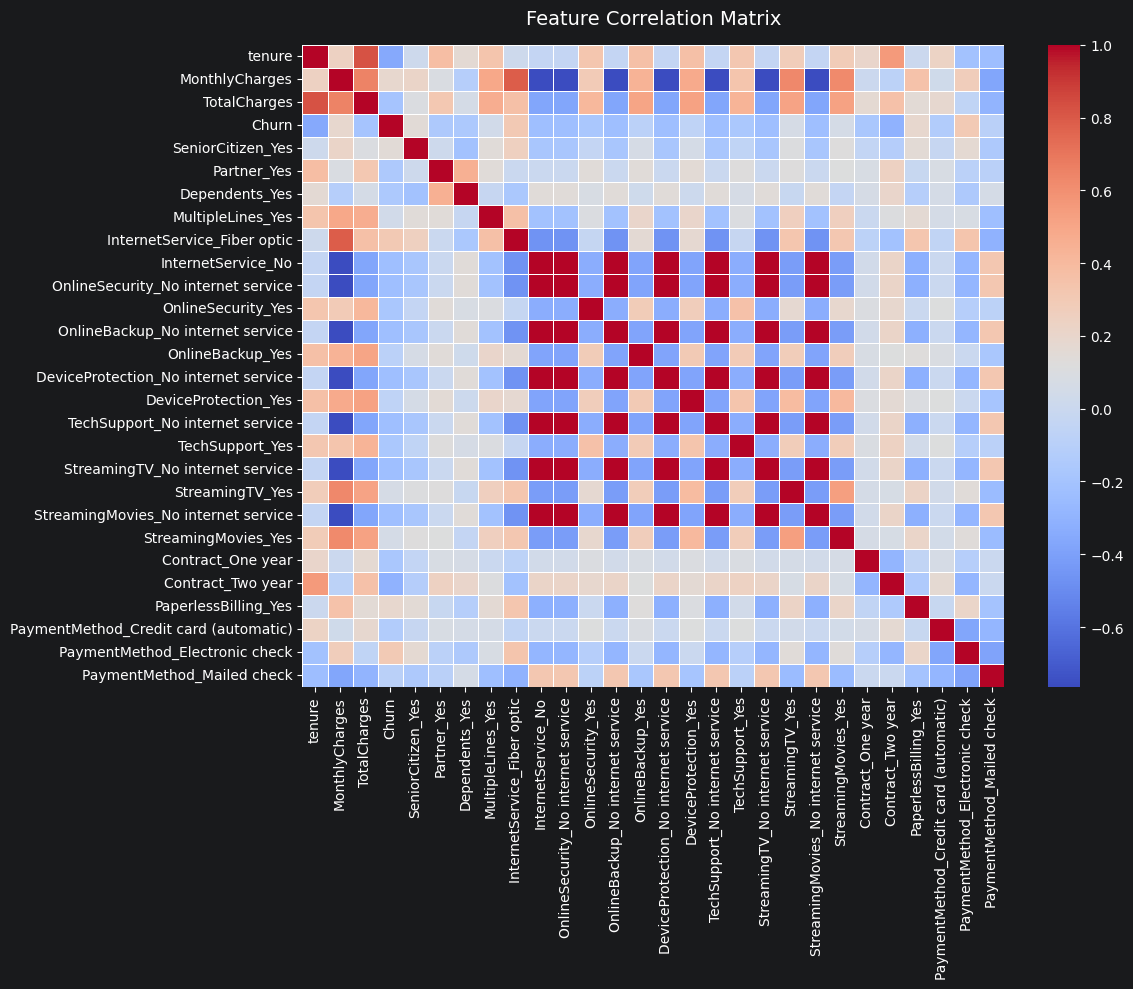

In [35]:
plt.figure(figsize=(12, 10))

corr_matrix = df_filtered.corr()

sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Feature Correlation Matrix", fontsize=14, pad=15)
plt.tight_layout()
plt.show()


In [38]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

# Assuming X_train and X_test are already created from your encoded df_filtered

# =====================================================================
# STEP 1: ELIMINATE MULTICOLLINEARITY USING VIF
# =====================================================================
# Features that track the same thing (like tenure, MonthlyCharges, TotalCharges)
# can confuse linear models. We remove features with a VIF > 10.

def calculate_vif(X_data):
    vif_df = pd.DataFrame()
    vif_df["Feature"] = X_data.columns
    vif_df["VIF"] = [variance_inflation_factor(X_data.values, i) for i in range(X_data.shape[1])]
    return vif_df

# Keep looping and removing the highest VIF feature until all are under 10
X_vif = X_train.copy()
while True:
    vif_results = calculate_vif(X_vif)
    max_vif = vif_results["VIF"].max()
    if max_vif > 10:
        highest_vif_feature = vif_results.sort_values("VIF", ascending=False).iloc[0]["Feature"]
        print(f" Eliminating {highest_vif_feature} due to high VIF ({max_vif:.2f})")
        X_vif = X_vif.drop(columns=[highest_vif_feature])
    else:
        break

# Sync changes to both train and test sets
vif_features = X_vif.columns
X_train_vif = X_train[vif_features]
X_test_vif = X_test[vif_features]

print(f"\nVIF complete. Kept {len(vif_features)} features.")

# =====================================================================
# STEP 2: RECURSIVE FEATURE ELIMINATION (RFE)
# =====================================================================
# We will use a Random Forest model to rank the remaining features
# and automatically strip away the weakest ones until exactly 10 remain.

estimator = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
# Select the top 10 features
rfe = RFE(estimator=estimator, n_features_to_select=10, step=1)
rfe.fit(X_train_vif, y_train)

# Extract selected features
selected_features = X_train_vif.columns[rfe.support_]


for i, feature in enumerate(selected_features, 1):
    print(f"{i}. {feature}")

# Create final pruned datasets
X_train_final = X_train_vif[selected_features]
X_test_final = X_test_vif[selected_features]


 Eliminating OnlineSecurity_No internet service due to high VIF (inf)
 Eliminating InternetService_No due to high VIF (inf)
 Eliminating OnlineBackup_No internet service due to high VIF (inf)
 Eliminating StreamingMovies_No internet service due to high VIF (inf)
 Eliminating StreamingTV_No internet service due to high VIF (inf)
 Eliminating DeviceProtection_No internet service due to high VIF (inf)
 Eliminating MonthlyCharges due to high VIF (39.88)
 Eliminating TotalCharges due to high VIF (18.25)

VIF complete. Kept 19 features.
1. tenure
2. Partner_Yes
3. InternetService_Fiber optic
4. OnlineSecurity_Yes
5. TechSupport_No internet service
6. StreamingMovies_Yes
7. Contract_One year
8. Contract_Two year
9. PaperlessBilling_Yes
10. PaymentMethod_Electronic check


Running GridSearchCV for Random Forest Optimization...
Best parameters : {'class_weight': 'balanced', 'max_depth': 8, 'min_samples_split': 10, 'n_estimators': 100}

OPTIMIZED RANDOM FOREST PERFORMANCE (10 FEATURES)
              precision    recall  f1-score   support

           0       0.92      0.73      0.81      1035
           1       0.52      0.81      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409

Overall Accuracy: 75.0887%

LOGISTIC REGRESSION (PRUNED) PERFORMANCE (10 FEATURES)
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.50      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409

Overall Accuracy: 73.8112%

DECISION TREE (PRUNE

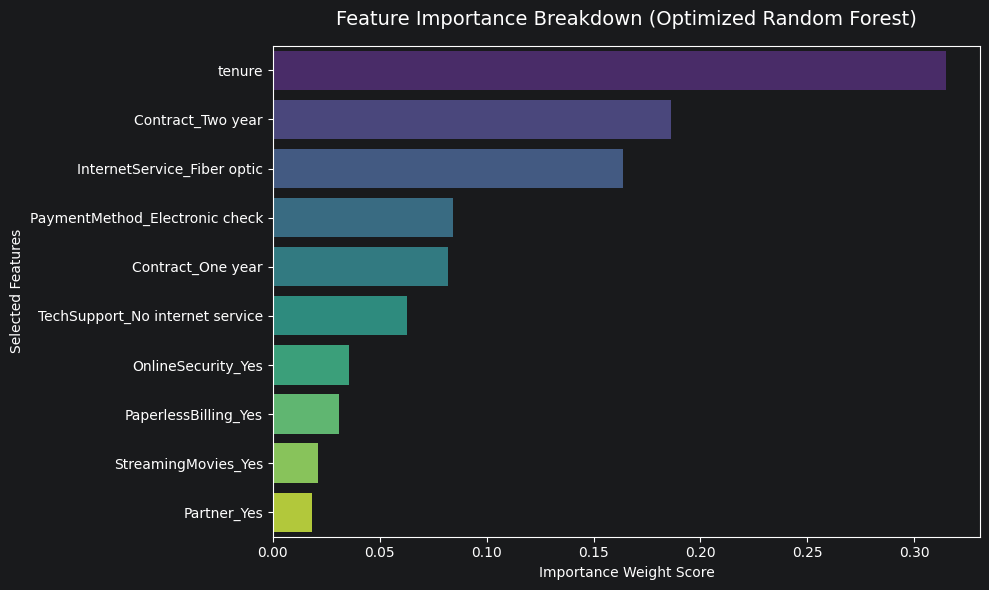

In [41]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

print("Running GridSearchCV for Random Forest Optimization...")

# Focus parameters on controlling tree depth, split requirements, and estimator counts
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [4, 6, 8, 10],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced'] # Ensures minority class (Churn) gets prioritized
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# Using 'f1' as scoring helps find the optimal balance between Precision and Recall
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train_final, y_train)

# Extract the tuned model
best_rf_model = grid_search.best_estimator_

print(f"Best parameters : {grid_search.best_params_}\n")

# STEP 2: RE-TRAIN ALL THREE MODELS ON CHOSEN FEATURES
models = {
    "Optimized Random Forest": best_rf_model,
    "Logistic Regression (Pruned)": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "Decision Tree (Pruned)": DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42)
}

# Run pipeline over pruned features
for name, model in models.items():
    model.fit(X_train_final, y_train)
    preds = model.predict(X_test_final)

    print(f"{name.upper()} PERFORMANCE (10 FEATURES)")
    print(classification_report(y_test, preds))
    print(f"Overall Accuracy: {accuracy_score(y_test, preds):.4%}\n")

# =====================================================================
# STEP 3: PLOT FEATURE IMPORTANCE FOR THE OPTIMIZED RANDOM FOREST
# =============================================
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
#
# ========================
importances = best_rf_model.feature_importances_
feature_imp_df = pd.DataFrame({
    'Feature': X_train_final.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Feature Importance Breakdown (Optimized Random Forest)', fontsize=14, pad=15)
plt.xlabel('Importance Weight Score')
plt.ylabel('Selected Features')
plt.tight_layout()
plt.show()


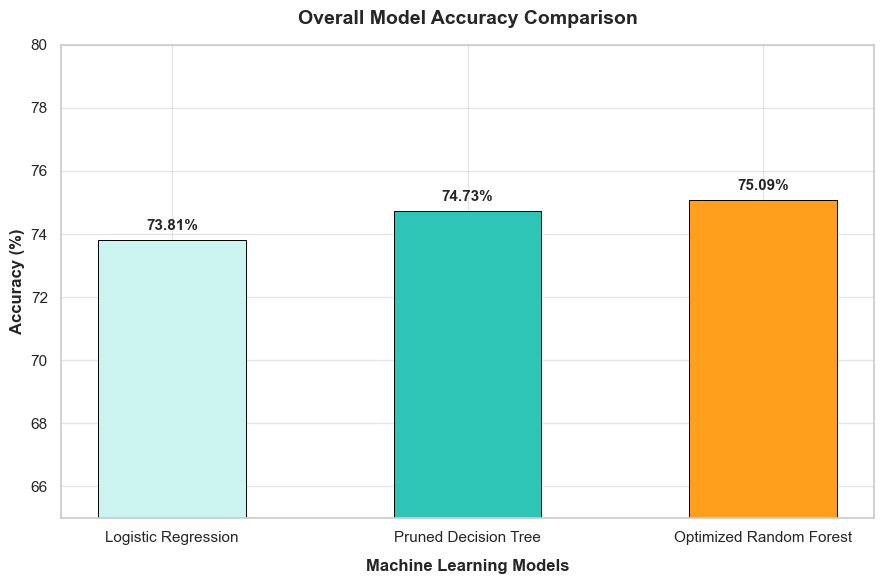

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

models = ['Logistic Regression', 'Pruned Decision Tree', 'Optimized Random Forest']
accuracies = [73.81, 74.73, 75.09]

sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 6))

colors = ['#cbf3f0', '#2ec4b6', '#ff9f1c']  # Clean, modern palette
bars = plt.bar(models, accuracies, color=colors, width=0.5, edgecolor='black', linewidth=0.7)

plt.title('Overall Model Accuracy Comparison', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
plt.xlabel('Machine Learning Models', fontsize=12, fontweight='bold', labelpad=10)
plt.ylim(65, 80)  # Zoomed axis to cleanly highlight the relative performance gaps

for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.2f}%',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 5),  # 5 points vertical offset
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()
